In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import simpy
import pandas as pd
from collections import Counter
from scipy.stats import ks_1samp
from scipy.linalg import expm
from lifelines.statistics import logrank_test
from scipy.linalg import norm

### Discrete-time model: Simulation / Estimation of Breast Cancer

Task 1

Empirical Proportion of Local Recurrence: 0.7120
95% Monte Carlo Confidence Interval: [0.6839, 0.7401]


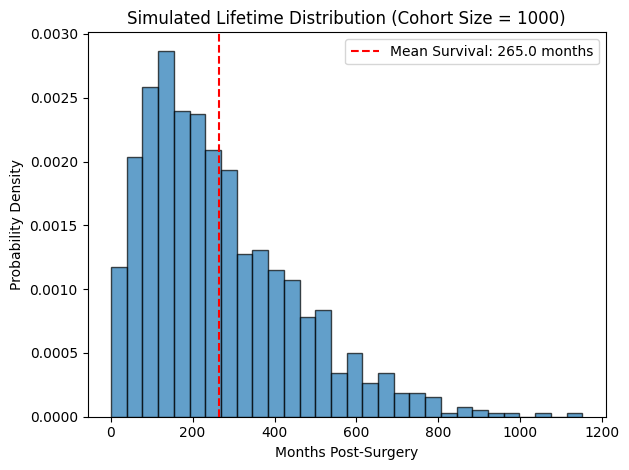

In [91]:
# Probability Matrix
# index 0: POST-OPERATION
# index 1: LOCAL RECURRENCE
# index 2: DISTANT METASTASIS
# index 3: JOINT RECURRENCE
# index 4: DEATH

P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
              [0, 0.986, 0.005, 0.004, 0.005],
              [0, 0, 0.992, 0.003, 0.005],
              [0, 0, 0, 0.991, 0.009],
              [0, 0, 0, 0, 1]])


# Assume that one time step equals one month. Simulate 1000 women, all 
# starting in state 1, until death. Summarize the lifetime distribution of the
# women, after surgery, for example using a histogram. In what proportion of
# women does the cancer eventually reappear, locally?
np.random.seed(42)
n = 1000

def simulate_patient_path(P):
    current_state = 0  # Start in State 1 (Index 0)
    months = 0
    visited_local_recurrence = False
    
    while current_state != 4:  # Loop until reaching State 5 (Index 4)
        # Check if the patient is currently in a local recurrence state (State 2 or State 4)
        if current_state == 1 or current_state == 3:
            visited_local_recurrence = True
            
        # Sample the next state according to the transition vector for the current state
        current_state = np.random.choice(5, p=P[current_state])
        months += 1

    return months, visited_local_recurrence

lifetimes = []
local_recurrence_flags = []

for _ in range(n):
    months, had_local_rec = simulate_patient_path(P)
    lifetimes.append(months)
    local_recurrence_flags.append(had_local_rec)

# Compute empirical proportion
prop_local_rec = np.mean(local_recurrence_flags)

# Quantify Monte Carlo Error using a Wald Confidence Interval
mc_se = np.sqrt((prop_local_rec * (1 - prop_local_rec)) / n)
ci_lower = prop_local_rec - 1.96 * mc_se
ci_upper = prop_local_rec + 1.96 * mc_se

print(f"Empirical Proportion of Local Recurrence: {prop_local_rec:.4f}")
print(f"95% Monte Carlo Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Visualizing the Lifetime Distribution using a Density Histogram
plt.hist(lifetimes, bins=30, edgecolor='black', alpha=0.7, density=True)
plt.axvline(np.mean(lifetimes), color='red', linestyle='--', linewidth=1.5, 
            label=f'Mean Survival: {np.mean(lifetimes):.1f} months')
plt.xlabel('Months Post-Surgery')
plt.ylabel('Probability Density')
plt.title('Simulated Lifetime Distribution (Cohort Size = 1000)')
plt.legend()
plt.tight_layout()

# there is a 71.2% percent chance that a woman will enter stage 2 or stage 4 again in her lifetime.

Task 2

In [92]:
current_states = np.zeros(n, dtype=int) 
had_local_recurrence = np.zeros(n, dtype=bool)
individual_lifetimes = np.zeros(n, dtype=int)

cohort_state_history = []

t = 0
while np.any(current_states < 4): 
    

    counts_at_t = np.bincount(current_states, minlength=5)
    cohort_state_history.append(counts_at_t)
    
    # For every woman, update their survival time if they have not died yet
    individual_lifetimes[current_states < 4] += 1
    
    # Update individual transitions
    for i in range(n):
        state = current_states[i]
        if state < 4:  
            next_state = np.random.choice(5, p=P[state])
            current_states[i] = next_state
            
            # flag if they just entered or are passing through a local recurrence state
            if next_state == 1 or next_state == 3:
                had_local_recurrence[i] = True

    t += 1

cohort_state_history = np.array(cohort_state_history)
observed_counts_120 = cohort_state_history[120]
print(f"Empirical State Distribution at t=120: {observed_counts_120}")

# Set the theoretical proportions of women being at each state, at t = 120
p0 = np.array([1, 0, 0, 0, 0])

P_120 = np.linalg.matrix_power(P, 120)
p_120_theoretical = p0 @ P_120

expected_counts = n * p_120_theoretical
print("Theoretical State Distribution", expected_counts)

Empirical State Distribution at t=120: [365 167 173  59 236]
Theoretical State Distribution [359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]


In [93]:
chi2_stat, p_value = stats.chisquare(f_obs=observed_counts_120, f_exp=expected_counts)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Fail to reject H0: The empirical distribution perfectly matches theoretical expectations.")
else:
    print("Reject H0: Significant deviation found between simulation and theory.")

Chi-Square Statistic: 2.5209
p-value: 0.6409
Fail to reject H0: The empirical distribution perfectly matches theoretical expectations.


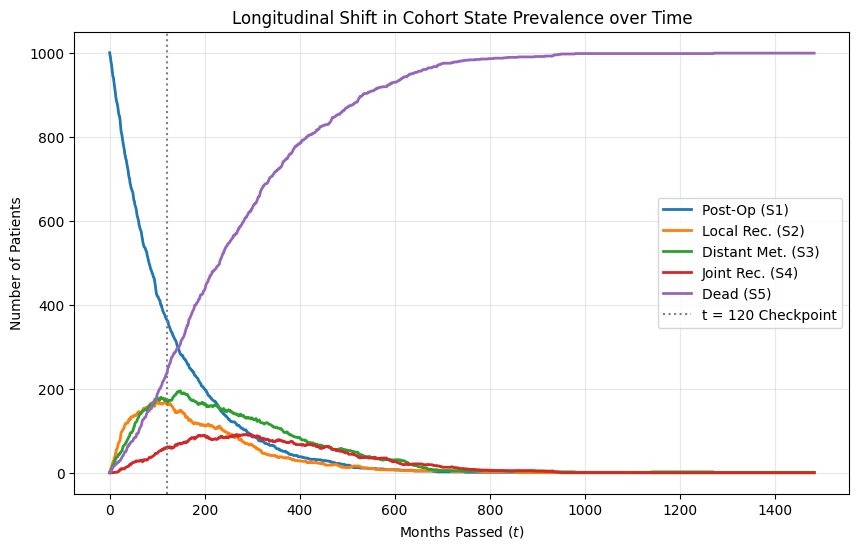

In [94]:
plt.figure(figsize=(10, 6))
states_labels = ['Post-Op (S1)', 'Local Rec. (S2)', 'Distant Met. (S3)', 'Joint Rec. (S4)', 'Dead (S5)']

for state_idx in range(5):
    plt.plot(cohort_state_history[:, state_idx], label=states_labels[state_idx], lw=2)

plt.axvline(120, color='gray', linestyle=':', label='t = 120 Checkpoint')
plt.xlabel('Months Passed ($t$)')
plt.ylabel('Number of Patients')
plt.title('Longitudinal Shift in Cohort State Prevalence over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Task 3

<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_35684/3645968074.py:26: SyntaxWarning: invalid escape sequence '\h'
  plt.step(sorted_lifetimes, ecdf, label='Empirical CDF ($\hat{F}_n(t)$)', where='post', lw=2)


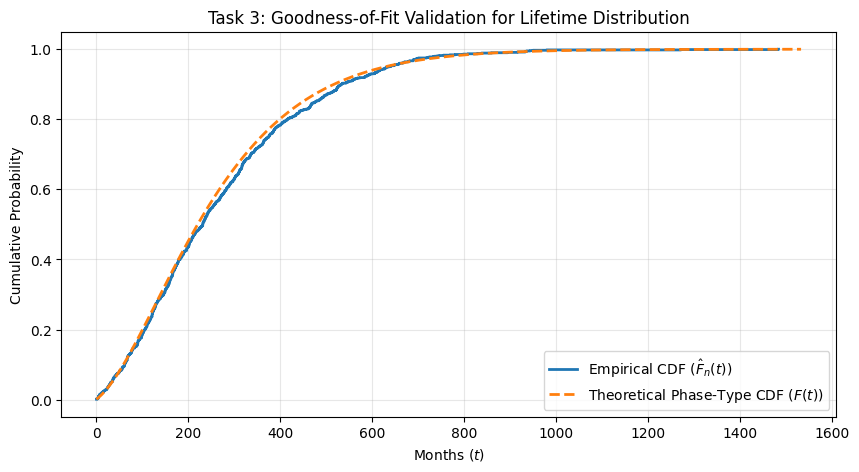

In [95]:
Ps = P[:4, :4]
ps = P[:4, 4]
pi = np.array([1, 0, 0, 0])

# theoretical PMF & CDF across a time horizon
max_time = int(np.max(individual_lifetimes)) + 50
t_range = np.arange(1, max_time)
theoretical_pmf = []

for t in t_range:
    # using t-1 to account for the discrete-time survival steps
    mat_power = np.linalg.matrix_power(Ps, t - 1)
    prob_t = pi @ mat_power @ ps
    theoretical_pmf.append(prob_t)

theoretical_pmf = np.array(theoretical_pmf)
theoretical_cdf = np.cumsum(theoretical_pmf)

# Empirical CDF (eCDF) from your simulated lifetimes
# individual_lifetimes comes from your cohort simulation loop
sorted_lifetimes = np.sort(individual_lifetimes)
ecdf = np.arange(1, len(sorted_lifetimes) + 1) / len(sorted_lifetimes)

# Statistical Visualization
plt.figure(figsize=(10, 5))
plt.step(sorted_lifetimes, ecdf, label='Empirical CDF ($\hat{F}_n(t)$)', where='post', lw=2)
plt.plot(t_range, theoretical_cdf, label='Theoretical Phase-Type CDF ($F(t)$)', linestyle='--', lw=2)
plt.xlabel('Months ($t$)')
plt.ylabel('Cumulative Probability')
plt.title('Task 3: Goodness-of-Fit Validation for Lifetime Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Task 4

In [96]:
np.random.seed(42)

def simulate_single_patient_with_history(P):
    """Simulates an individual, returning her total lifetime and state history matrix."""
    current_state = 0
    months = 0
    state_history = []
    
    while current_state != 4:
        state_history.append(current_state)
        current_state = np.random.choice(5, p=P[current_state])
        months += 1
        
    state_history.append(current_state) # Append final death state
    return months, state_history

# Rejection Sampling Loop
accepted_lifetimes = []
target_sample_size = 1000
total_simulated = 0

while len(accepted_lifetimes) < target_sample_size:
    total_simulated += 1
    months, history = simulate_single_patient_with_history(P)
    
    # Did a patient survive past the first 12 months?
    if len(history) > 12 and history[12] != 4:
        
        # Did cancer reappear within the first 12 months?
        history_first_year = history[:13] # Elements t=0 to t=12
        had_recurrence_first_year = any(s in [1, 2, 3] for s in history_first_year)
        
        if had_recurrence_first_year:
            accepted_lifetimes.append(months)

accepted_lifetimes = np.array(accepted_lifetimes)

# Statistical Analysis of the Conditional Cohort
conditional_mean_lifetime = np.mean(accepted_lifetimes)
# Standard error of the conditional mean
conditional_se = np.std(accepted_lifetimes, ddof=1) / np.sqrt(target_sample_size)

print(f"Rejection Sampling Efficiency: {(target_sample_size / total_simulated)*100:.2f}% of simulations accepted.")
print(f"Estimated Expected Lifetime (Conditional): {conditional_mean_lifetime:.2f} months")
print(f"95% Confidence Interval for Conditional Expected Lifetime: "
      f"[{conditional_mean_lifetime - 1.96*conditional_se:.2f}, {conditional_mean_lifetime + 1.96*conditional_se:.2f}]")


# from Task 1, the mean survival time for the entire cohort was 265 months.
# The mean survival time of cohort that got cancer repeatedly was 178.72 months.
# This indicates that patients who experience a recurrence of cancer within the first year have a significantly lower expected lifetime compared to the overall cohort (~7 years), highlighting the impact of early recurrence on long-term survival outcomes.

Rejection Sampling Efficiency: 7.69% of simulations accepted.
Estimated Expected Lifetime (Conditional): 178.72 months
95% Confidence Interval for Conditional Expected Lifetime: [169.16, 188.27]


In [97]:
# What fraction of women die within the first 350 months? 

num_experiments = 10
num_women = 200

# Simulate the lifetimes
np.random.seed(42)
crude_fractions = []  
mean_lifetimes = []  

pi = np.array([1, 0, 0, 0])
mu_Z = float(pi @ np.linalg.inv(np.eye(4) - Ps) @ np.ones(4))

all_X = []
all_Z = []

for experiment in range(num_experiments):
    experiment_X = []
    experiment_Z = []
    
    for j in range(num_women):
        months, history = simulate_single_patient_with_history(P)
        
        # X: Indicator if they died within 350 months (Target)
        x_val = 1.0 if months < 350 else 0.0
        # Z: The raw lifetime (Control Variate)
        z_val = float(months)
        
        experiment_X.append(x_val)
        experiment_Z.append(z_val)
        all_X.append(x_val)
        all_Z.append(z_val)
        
    # Record the batch means for each of the 100 experiments
    crude_fractions.append(np.mean(experiment_X))
    mean_lifetimes.append(np.mean(experiment_Z))

# Convert everything to numpy arrays
crude_fractions = np.array(crude_fractions)
mean_lifetimes = np.array(mean_lifetimes)
all_X = np.array(all_X)
all_Z = np.array(all_Z)

# Calculate the Optimal Control Variate Coefficient 'c'
mean_all_X = np.mean(all_X)
mean_all_Z = np.mean(all_Z)

cov_XZ = np.mean((all_X - mean_all_X) * (all_Z - mean_all_Z))
var_Z = np.var(all_Z, ddof=1)

c = -cov_XZ / var_Z


controlled_fractions = crude_fractions + c * (mean_lifetimes - mu_Z)

# Variance Reduction Analysis
var_crude = np.var(crude_fractions, ddof=1)
var_controlled = np.var(controlled_fractions, ddof=1)
variance_reduction_percent = (1 - (var_controlled / var_crude)) * 100

# Summary
print("--- Variance Reduction Analysis via Control Variates ---")
print(f"Optimal Coefficient (c): {c:.6f}")
print(f"Theoretical Mean Lifetime (mu_Z): {mu_Z:.2f} months\n")

print(f"Crude MC Estimator Mean Fraction: {np.mean(crude_fractions):.4f}")
print(f"Crude MC Estimator Variance across experiments: {var_crude:.6f}\n")

print(f"Control Variate Estimator Mean Fraction: {np.mean(controlled_fractions):.4f}")
print(f"Control Variate Estimator Variance across experiments: {var_controlled:.6f}\n")

print(f"Reduction in Variance: {variance_reduction_percent:.2f}%")

# from 100 simulation runs of 200 women, 72% of women died within 350 months


--- Variance Reduction Analysis via Control Variates ---
Optimal Coefficient (c): 0.001882
Theoretical Mean Lifetime (mu_Z): 262.37 months

Crude MC Estimator Mean Fraction: 0.7250
Crude MC Estimator Variance across experiments: 0.001094

Control Variate Estimator Mean Fraction: 0.7353
Control Variate Estimator Variance across experiments: 0.000444

Reduction in Variance: 59.43%


## Part 2: Continuous-Time model

Mean Lifetime: 256.37 months, 95% CI: [244.32, 268.42]
SD of Lifetime: 194.38 months, 95% CI: [186.22, 203.29]


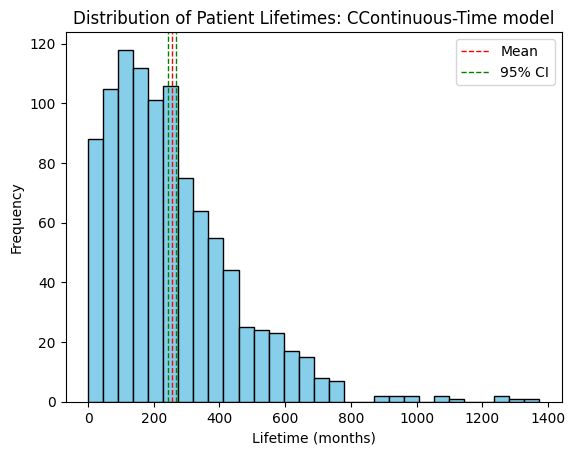

In [98]:
Q = np.array([
    [-0.0085,  0.005,  0.0025,  0.000,  0.001],
    [ 0.0000, -0.014,  0.005,  0.004,  0.005],
    [ 0.0000,  0.000, -0.008,  0.003,  0.005],
    [ 0.0000,  0.000,  0.000, -0.009,  0.009],
    [ 0.0000,  0.000,  0.000,  0.000,  0.000]
])

P_embedded = np.zeros_like(Q)
for i in range(4):
    total_exit_rate = -Q[i, i]
    P_embedded[i, :] = Q[i, :] / total_exit_rate
    P_embedded[i, i] = 0.0

# state of death is absorbing
P_embedded[4, 4] = 1.0



def simulate_continuous_patient(Q, P_embed):
    current_state = 0 # State 1 (Index 0)
    current_time = 0.0
    
    timeline = [(current_state, current_time)]
    
    while current_state != 4: # Loop until Death (Index 4)
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(scale=1.0 / rate)
        current_time += sojourn_time
        
        current_state = np.random.choice(5, p=P_embed[current_state])
        
        timeline.append((current_state, current_time))
        
    return current_time, timeline


np.random.seed(42)
num_women = 1000

lifetimes = []
cohort_timelines = []

for _ in range(num_women):
    total_lifetime, patient_timeline = simulate_continuous_patient(Q, P_embedded)
    lifetimes.append(total_lifetime)
    cohort_timelines.append(patient_timeline)

lifetimes = np.array(lifetimes)

# Mean Calculations
mean_val = np.mean(lifetimes)
se_mean = np.std(lifetimes, ddof=1) / np.sqrt(num_women)
mean_ci = [mean_val - 1.96 * se_mean, mean_val + 1.96 * se_mean]

# Standard Deviation Calculations (Using Chi-Square for Sample Variance)
df = num_women - 1
sample_var = np.var(lifetimes, ddof=1)
chi2_lower = stats.chi2.ppf(0.025, df)
chi2_upper = stats.chi2.ppf(0.975, df)

sd_val = np.sqrt(sample_var)
sd_ci = [np.sqrt(df * sample_var / chi2_upper), np.sqrt(df * sample_var / chi2_lower)]

print(f"Mean Lifetime: {mean_val:.2f} months, 95% CI: [{mean_ci[0]:.2f}, {mean_ci[1]:.2f}]")
print(f"SD of Lifetime: {sd_val:.2f} months, 95% CI: [{sd_ci[0]:.2f}, {sd_ci[1]:.2f}]")

# Plot the histogram of the results
plt.hist(lifetimes, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Patient Lifetimes: CContinuous-Time model")
plt.xlabel("Lifetime (months)")
plt.ylabel("Frequency")
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean_ci[0], color='green', linestyle='dashed', linewidth=1)
plt.axvline(mean_ci[1], color='green', linestyle='dashed', linewidth=1)
plt.legend({"Mean": mean_val, "95% CI": mean_ci})
plt.show()

In [99]:
# In what proportion of women has the cancer reappeared distantly after 30.5 months?
distant_recurrence_at_30_5 = 0

for timeline in cohort_timelines:
    has_distant_by_30_5 = False
    
    # Look through the states this woman entered and when she entered them
    for state, time_entered in timeline:
        # If she transitioned to State 3 or 4 before or at 30.5 months
        if (state == 2 or state == 3) and (time_entered <= 30.5):
            has_distant_by_30_5 = True
            break # Condition met, check next patient
            
    if has_distant_by_30_5:
        distant_recurrence_at_30_5 += 1

prop_distant = distant_recurrence_at_30_5 / num_women
print(f"Proportion of women with distant metastasis by 30.5 months: {prop_distant:.4f}")

Proportion of women with distant metastasis by 30.5 months: 0.0840


Task 8

In [100]:
Qs = Q[:4, :4] 
p0 = np.array([1, 0, 0, 0])    # Initial distribution vector
ones_vector = np.ones((4, 1))  # Column vector of ones

def theoretical_cdf(t):
    """
    Computes the exact continuous Phase-Type CDF: F(t) = 1 - p0 * exp(Qs * t) * 1
    Safely handles SciPy's internal array streaming.
    """
    def compute_single_cdf(ti):
        val = p0 @ expm(Qs * float(ti)) @ ones_vector
        return 1.0 - float(np.squeeze(val).item())
    
    # 2. Use numpy's native vectorization engine to scale it to any input shape SciPy throws at it
    vectorized_func = np.vectorize(compute_single_cdf)
    return vectorized_func(t)

# Kolmogorov - Smirnov test
ks_stat, p_value = ks_1samp(lifetimes, theoretical_cdf)

# 4. Print Rigorous Summary Results
print(" Goodness of fit test ")
print(f"Kolmogorov-Smirnov D-Statistic : {ks_stat:.5f}")
print(f"P-Value                         : {p_value:.5f}")
print("--------------------------------------------------------------------")

alpha = 0.05
if p_value > alpha:
    print(f"Conclusion: p-value > {alpha}. Fail to reject the null hypothesis (H0).\n"
          f"The empirical continuous lifetime distribution matches the theoretical\n"
          f"distribution with statistical consistency.")
else:
    print(f"Conclusion: p-value <= {alpha}. Reject the null hypothesis (H0).\n"
          f"There is a statistically significant systematic deviation between your\n"
          f"simulation loop logic and the continuous-time theory.")

 Goodness of fit test 
Kolmogorov-Smirnov D-Statistic : 0.02386
P-Value                         : 0.61097
--------------------------------------------------------------------
Conclusion: p-value > 0.05. Fail to reject the null hypothesis (H0).
The empirical continuous lifetime distribution matches the theoretical
distribution with statistical consistency.


Task 9

<>:53: SyntaxWarning: invalid escape sequence '\h'
<>:53: SyntaxWarning: invalid escape sequence '\h'
/var/folders/g6/d93by81s77b0lq36mrl7nv8m0000gn/T/ipykernel_35684/1972408730.py:53: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Estimated Survival Probability $\hat{S}(t)$', fontsize=11)


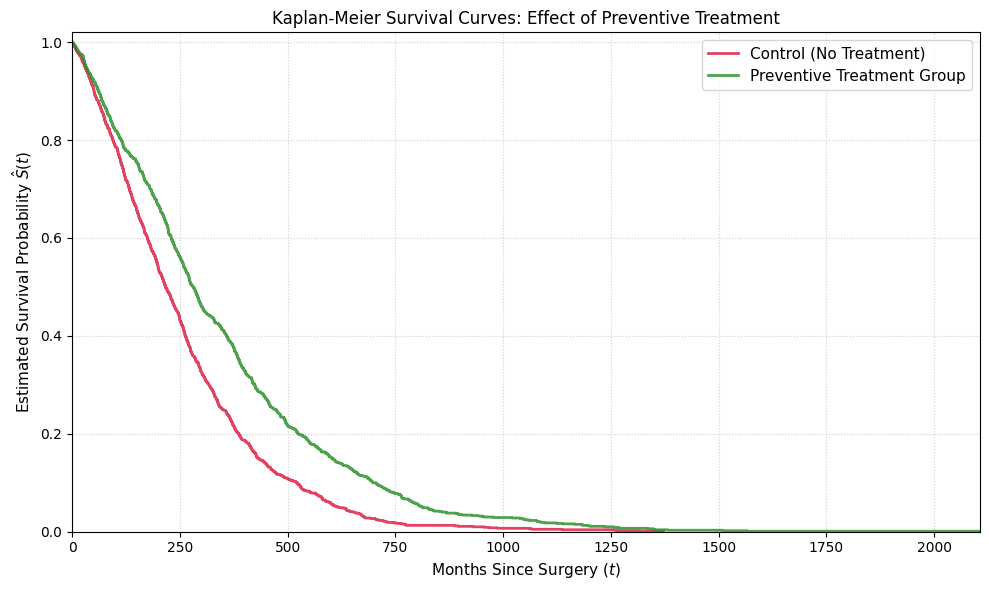

Mean Survival - Control group  : 256.37 months
Mean Survival - Treatment group: 343.18 months


In [101]:
np.random.seed(42)

num_women = 1000

# new treatment rate matrix
Q_tx = np.array([
    [-0.00475,  0.0025,  0.00125, 0.000,  0.001],
    [ 0.0000,  -0.007,   0.000,   0.002,  0.005],
    [ 0.0000,   0.000,  -0.008,   0.003,  0.005],
    [ 0.0000,   0.000,   0.000,  -0.009,  0.009],
    [ 0.0000,   0.000,   0.000,   0.000,  0.000]
])

# Embedding the treatment transition probabilities
P_tx_embed = np.zeros_like(Q_tx)
for i in range(4):
    total_exit_rate = -Q_tx[i, i]
    P_tx_embed[i, :] = Q_tx[i, :] / total_exit_rate
    P_tx_embed[i, i] = 0.0
P_tx_embed[4, 4] = 1.0


lifetimes_treatment = []

for _ in range(num_women):
    total_lifetime, _ = simulate_continuous_patient(Q_tx, P_tx_embed)
    lifetimes_treatment.append(total_lifetime)

lifetimes_treatment = np.array(lifetimes_treatment)

# Sort both lifetime vectors to compute their empirical survival curves
sorted_control = np.sort(lifetimes)            # From Task 7
sorted_treatment = np.sort(lifetimes_treatment)  # From Task 9

# Create the step percentiles (y-axis fractions dropping from 1 down to 0)
km_y_control = 1.0 - (np.arange(1, len(sorted_control) + 1) / len(sorted_control))
km_y_treatment = 1.0 - (np.arange(1, len(sorted_treatment) + 1) / len(sorted_treatment))


plt.figure(figsize=(10, 6))

# Plot Control Group (Task 7 data)
plt.step(sorted_control, km_y_control, where='post', 
         color='crimson', alpha=0.8, lw=2, label='Control (No Treatment)')

# Plot Treatment Group (Task 9 data)
plt.step(sorted_treatment, km_y_treatment, where='post', 
         color='forestgreen', alpha=0.8, lw=2, label='Preventive Treatment Group')

# Labeling and Formatting with Rigor
plt.title('Kaplan-Meier Survival Curves: Effect of Preventive Treatment', fontsize=12)
plt.xlabel('Months Since Surgery ($t$)', fontsize=11)
plt.ylabel('Estimated Survival Probability $\hat{S}(t)$', fontsize=11)
plt.ylim(0, 1.02)
plt.xlim(0, max(np.max(sorted_control), np.max(sorted_treatment)))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print empirical mean comparison
print(f"Mean Survival - Control group  : {np.mean(sorted_control):.2f} months")
print(f"Mean Survival - Treatment group: {np.mean(sorted_treatment):.2f} months")

Task 10 (Optional)

In [102]:
# Null Hypothesis: There is no difference in the survival functions of the Control group and the Treatment group.
# Alternative Hypothesis: There is a statistically significant difference in the survival functions between the two groups.

# Create a DataFrame for the Control Group
df_control = pd.DataFrame({
    'durations': lifetimes,
    'events': np.ones(len(lifetimes)),
    'group': 'Control'
})

# Create a DataFrame for the Treatment Group
df_treatment = pd.DataFrame({
    'durations': lifetimes_treatment,
    'events': np.ones(len(lifetimes_treatment)),
    'group': 'Treatment'
})

# Log-rank Test
results = logrank_test(
    durations_A=df_control['durations'],
    durations_B=df_treatment['durations'],
    event_observed_A=df_control['events'],
    event_observed_B=df_treatment['events']
)

print("Log-Rank Test Summary")
print(f"Log-rank Test Chi-Square Statistic : {results.test_statistic:.4f}")
print(f"P-Value                             : {results.p_value:.4e}")

alpha = 0.05
if results.p_value < alpha:
    print(f"Conclusion: p-value < {alpha}. Reject the null hypothesis (H0).\n"
          f"The preventive treatment has a highly statistically significant effect\n"
          f"on the survival function of the women.")
else:
    print(f"Conclusion: p-value >= {alpha}. Fail to reject the null hypothesis (H0).\n"
          f"There is no statistically significant survival difference between the cohorts.")


Log-Rank Test Summary
Log-rank Test Chi-Square Statistic : 75.0161
P-Value                             : 4.6690e-18
Conclusion: p-value < 0.05. Reject the null hypothesis (H0).
The preventive treatment has a highly statistically significant effect
on the survival function of the women.


Task 11

#### 1. Assumptions Eliminated by Shifting to Continuous Time
* **Rigid Discretization & Interval-Censoring:** In the discrete-time model (DTMC), patients were forced to make clinical transitions exactly once a month. However, it is not a realistic scenario in real life.
* **Elimination Benefit:** Shifting to a continuous-time model (CTMC) allows transitions to occur fluidly at any fraction of a month. It eliminates the artifactual delay where a patient moving from State 1 to State 2 was locked in that state for at least 30 days before moving onward. Multi-stage rapid health decline within a short window is now natively supported.

#### 2. Assumptions Added by Shifting to Continuous Time
* **Exponentially Distributed Sojourn Times:** While we gained timing flexibility, standard CTMCs enforce that the time spent (sojourn time) in any transient state follows an *Exponential distribution*.
* **Constant Hazard Risk:** The exponential distribution possesses a strict, flat rate. This implies that the probability of transitioning out of a state in the next hour is exactly the same, regardless of whether the patient entered that state yesterday or 5 years ago.

#### 3. Extending the Model to Erlang-Distributed Sojourn Times (Adding Memory)
**The Clinical Dilemma:**
In oncology, the memoryless property is unrealistic. A patient who has managed a local recurrence for 3 years experiences different physical state and progressive mortality risks compared to a patient diagnosed yesterday. To capture this "wear-and-tear," we need a distribution with memory.

**The Solution: The Method of Stages (Erlang Distribution)**
An Erlang-$k$ distribution is mathematically defined as the **sum of $k$ independent, identically distributed exponential random variables**. We can exploit this property to build memory into our Markov chain without losing mathematical tractability by expanding our state space.


### Part 3
Task 12

In [103]:
# Use the same Q matrix as defined in Task 7
Q = np.array([
    [-0.0085,  0.005,  0.0025,  0.000,  0.001],
    [ 0.0000, -0.014,  0.005,  0.004,  0.005],
    [ 0.0000,  0.000, -0.008,  0.003,  0.005],
    [ 0.0000,  0.000,  0.000, -0.009,  0.009],
    [ 0.0000,  0.000,  0.000,  0.000,  0.000]
])

# Re-derive P_embedded for the internal path generator
P_embedded = np.zeros_like(Q)
for i in range(4):
    total_exit_rate = -Q[i, i]
    P_embedded[i, :] = Q[i, :] / total_exit_rate
    P_embedded[i, i] = 0.0

P_embedded[4, 4] = 1.0 

# set the seed 
np.random.seed(42)
num_women = 1000
screening_interval = 48

observed_screening_series = []

for i in range(num_women):
    current_state = 0
    current_time = 0.0
    timeline = [(current_state, current_time)]
    
    while current_state != 4:
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(scale=1.0 / rate)
        current_time += sojourn_time
        current_state = np.random.choice(5, p=P_embedded[current_state])
        timeline.append((current_state, current_time))
    
    # Extract the 4-Year Screenings Y(i)
    y_i = []
    check_time = 0.0
    patient_dead_and_recorded = False
    
    while not patient_dead_and_recorded:
        # Find what state the patient was in at exactly 'check_time'
        # We look for the last state entered before or exactly at check_time
        state_at_check = 0
        for state, time_entered in timeline:
            if time_entered <= check_time:
                state_at_check = state
            else:
                break
        
        # Convert index (0-4) to state labels (1-5) for proper project presentation
        y_i.append(state_at_check + 1)
        
        # If the state observed is 5 (Death), we stop tracking this patient
        if state_at_check == 4:
            patient_dead_and_recorded = True
            
        # Move to the next screening appointment (48 months later)
        check_time += screening_interval
        
    observed_screening_series.append(y_i)

print("--- Sample Screenings Vectors Y(i) (Observed State every 48 months) ---")
for idx in range(10):
    print(f"Woman {idx + 1}: {observed_screening_series[idx]}")


# The vectors will be of completely different lengths. 
# In 1st example, woman survived the first 48 months but died before month 96, thus her screening vecotr is [1, 1, 5].

--- Sample Screenings Vectors Y(i) (Observed State every 48 months) ---
Woman 1: [1, 1, 5]
Woman 2: [1, 1, 1, 1, 5]
Woman 3: [1, 1, 1, 5]
Woman 4: [1, 1, 1, 1, 1, 3, 5]
Woman 5: [1, 1, 2, 3, 4, 4, 5]
Woman 6: [1, 2, 3, 3, 3, 5]
Woman 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 4, 4, 5]
Woman 8: [1, 5]
Woman 9: [1, 3, 5]
Woman 10: [1, 1, 2, 2, 2, 2, 2, 2, 5]


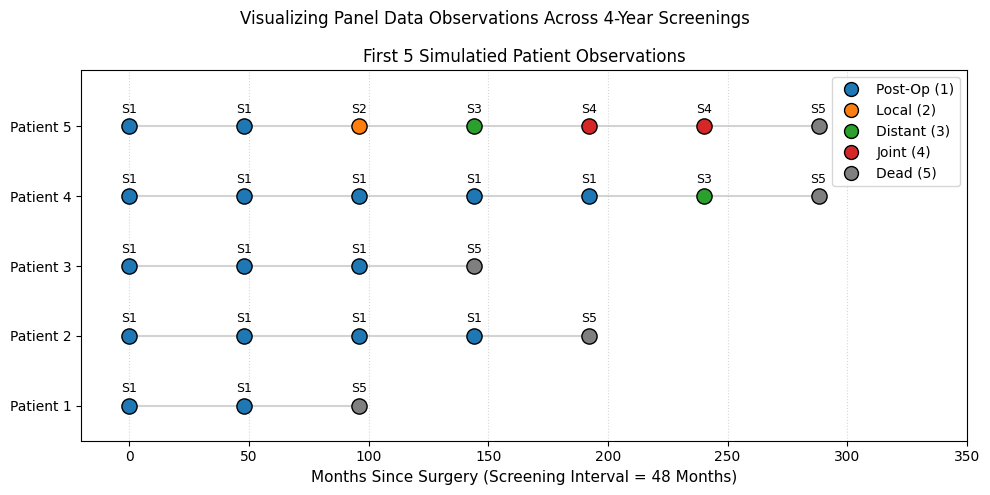

In [116]:
# Plot of the Screening Vectors
sample_y = [
    [1, 1, 5],
    [1, 1, 1, 1, 5],
    [1, 1, 1, 5],
    [1, 1, 1, 1, 1, 3, 5],
    [1, 1, 2, 3, 4, 4, 5]
]

plt.figure(figsize=(10, 5))
state_labels = {1: 'Post-Op (1)', 2: 'Local (2)', 3: 'Distant (3)', 4: 'Joint (4)', 5: 'Dead (5)'}
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728', 5: '#7f7f7f'}

# Plot each patient as a horizontal track
for idx, patient_vec in enumerate(sample_y):
    # X-axis points are screening intervals: 0, 48, 96, 144...
    times = [t * 48 for t in range(len(patient_vec))]
    
    # Draw the connecting baseline line
    plt.plot(times, [idx] * len(times), color='lightgray', zorder=1, linestyle='-')
    
    # Scatter plot the discrete screening observations
    for t_idx, state in enumerate(patient_vec):
        plt.scatter(times[t_idx], idx, color=colors[state], s=120, edgecolors='black', zorder=2)
        # Label the state next to the dot for clarity
        plt.text(times[t_idx], idx + 0.15, f"S{state}", ha='center', va='bottom', fontsize=9)

# Formatting
plt.yticks(range(len(sample_y)), [f"Patient {i+1}" for i in range(len(sample_y))])
plt.xlabel("Months Since Surgery (Screening Interval = 48 Months)", fontsize=11)
plt.suptitle("Visualizing Panel Data Observations Across 4-Year Screenings", fontsize=12)
plt.title("First 5 Simulatied Patient Observations", fontsize=12)
plt.xlim(-20, 350)
plt.ylim(-0.5, len(sample_y) - 0.2)
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Custom legend
markers = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[s], markersize=10, markeredgecolor='black') for s in range(1, 6)]
plt.legend(markers, [state_labels[s] for s in range(1, 6)], loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Task 13

In [110]:
# Setup for simulation

# Extract all 48-month transition intervals from our Task 12 sequences
observed_pairs = []
for y_i in observed_screening_series:
    for k in range(len(y_i) - 1):
        # Convert from 1-5 state labels to 0-4 python indexing
        start_state = y_i[k] - 1
        end_state = y_i[k+1] - 1
        observed_pairs.append((start_state, end_state))

True_Q = Q.copy()
structure_mask = (Q > 0)

def sample_valid_segment(start_state, end_state, max_time, Q_current):
    # Compute the embedded discrete chain probabilities for the current Q guess
    P_embed = np.zeros_like(Q_current)
    for i in range(4):
        total_exit_rate = -Q_current[i, i]
        if total_exit_rate > 0:
            P_embed[i, :] = Q_current[i, :] / total_exit_rate
            P_embed[i, i] = 0.0
    P_embed[4, 4] = 1.0

    while True:
        current_state = start_state
        current_time = 0.0
        
        local_N = np.zeros_like(Q_current)
        local_S = np.zeros(5)
        
        # If already dead, they just stay dead for the whole 48 months
        if current_state == 4:
            if end_state == 4:
                local_S[4] += max_time
                return local_N, local_S
            else:
                continue 
        
        while current_time < max_time and current_state != 4:
            rate = -Q_current[current_state, current_state]
            sojourn = np.random.exponential(scale=1.0 / rate)
            
            # If the holding time goes past the 48-month check, cut it off
            if current_time + sojourn >= max_time:
                local_S[current_state] += (max_time - current_time)
                current_time = max_time
                break
            else:
                local_S[current_state] += sojourn
                current_time += sojourn
                next_state = np.random.choice(5, p=P_embed[current_state])
                local_N[current_state, next_state] += 1
                current_state = next_state
        
        # If the patient dies early, accumulate the remaining interval time in state 5
        if current_state == 4 and current_time < max_time:
            local_S[4] += (max_time - current_time)
            
        # Rejection check: Only return if the simulation ended in the correct state
        if current_state == end_state:
            return local_N, local_S


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Initial guess Q(0)
Q_k = np.array([
    [-0.03,  0.01,  0.01,  0.00,  0.01],
    [ 0.00, -0.03,  0.01,  0.01,  0.01],
    [ 0.00,  0.00, -0.02,  0.01,  0.01],
    [ 0.00,  0.00,  0.00, -0.01,  0.01],
    [ 0.00,  0.00,  0.00,  0.00,  0.00]
])

max_iter = 10
tolerance = 1e-3
interval = 48.0

print("Running Monte Carlo EM iterations...")

# Main MCEM optimization loop
for iteration in range(max_iter):
    total_N = np.zeros_like(Q_k)
    total_S = np.zeros(5)
    
    # Loop over all patient panel observations (Steps 1 & 2)
    for y_i in observed_screening_series:
        for m in range(len(y_i) - 1):
            s_start = y_i[m] - 1
            s_end = y_i[m+1] - 1
            
            # Keep trying trajectories until we match the data boundaries
            seg_N, seg_S = sample_valid_segment(s_start, s_end, interval, Q_k)
            total_N += seg_N
            total_S += seg_S
            
    # Step 3: Standard MLE calculation (q_ij = N_ij / S_i)
    Q_next = np.zeros_like(Q_k)
    for i in range(4):
        for j in range(5):
            if i != j and structure_mask[i, j]:
                if total_S[i] > 0:
                    Q_next[i, j] = total_N[i, j] / total_S[i]
        
        # Force row sum constraint to zero, using Eq. 1 from the Project writeup
        Q_next[i, i] = -np.sum(Q_next[i, :])
        
    # Check convergence using the infinity norm
    diff = norm(Q_k - Q_next, np.inf)
    print(f"Iter {iteration+1:02d} - Diff: {diff:.6f}")
    
    Q_k = Q_next.copy()
    
    if diff < tolerance:
        print(f"Converged at iteration {iteration+1}!")
        break

# Display final comparison results
print("\nFinal Estimated Matrix Q:")
print(np.round(Q_k, 5))

print("\nTrue Generative Matrix Q:")
print(True_Q)

Running Monte Carlo EM iterations...
Iter 01 - Diff: 0.042905
Iter 02 - Diff: 0.001513
Iter 03 - Diff: 0.001660
Iter 04 - Diff: 0.000859
Converged at iteration 4!

Final Estimated Matrix Q:
[[-0.00842  0.00496  0.00237  0.       0.00109]
 [ 0.      -0.0146   0.00538  0.00397  0.00526]
 [ 0.       0.      -0.00816  0.00293  0.00523]
 [ 0.       0.       0.      -0.00927  0.00927]
 [ 0.       0.       0.       0.       0.     ]]

True Generative Matrix Q:
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
